# Lab 2 – Neural Network: Perceptron

**Course:** CS582 – Machine Learning  
**Topic:** Introduction to Neural Networks and the Perceptron Learning Algorithm

## Question 1: Threshold Neuron – Computing Outputs

A neuron is given with 2 inputs, weights $w_1 = 1$, $w_2 = 1$, and bias $b = -1.5$.  
The rule is simple: add up all the weighted inputs plus the bias. If the result is 0 or more, output 1. Otherwise, output 0.

Formula: $z = w_1 x_1 + w_2 x_2 + b$

| $x_1$ | $x_2$ | Calculation | $z$ | Output |
|-------|-------|-------------|-----|--------|
| 0 | 0 | $1(0) + 1(0) - 1.5$ | $-1.5$ | **0** |
| 1 | 0 | $1(1) + 1(0) - 1.5$ | $-0.5$ | **0** |
| 0 | 1 | $1(0) + 1(1) - 1.5$ | $-0.5$ | **0** |
| 1 | 1 | $1(1) + 1(1) - 1.5$ | $0.5$ | **1** |

This is the **AND gate** — the output is 1 only when both inputs are 1.

**Decision boundary equation:** $x_1 + x_2 = 1.5$, which is a straight line. Everything above it outputs 1, everything below outputs 0. The plot below shows this:

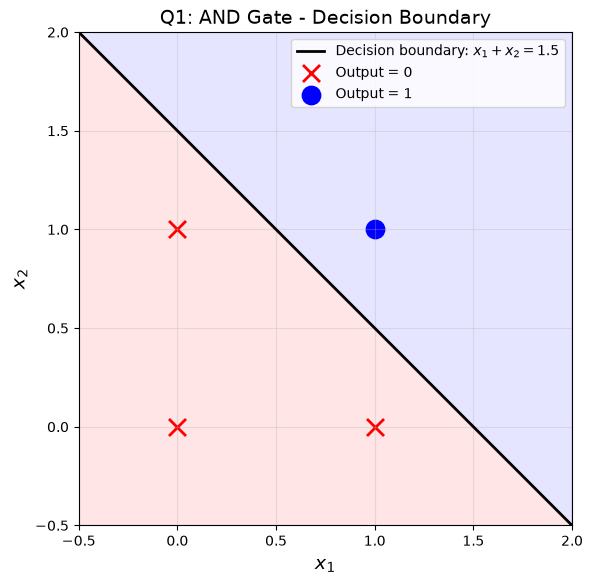

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Q1: Plot the discriminant function for the AND gate
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

# Decision boundary: x1 + x2 - 1.5 = 0 => x2 = -x1 + 1.5
x_line = np.linspace(-0.5, 2.0, 100)
y_line = -x_line + 1.5

# Input points
inputs = np.array([[0,0],[1,0],[0,1],[1,1]])
outputs = np.array([0, 0, 0, 1])

ax.plot(x_line, y_line, 'k-', linewidth=2, label='Decision boundary: $x_1 + x_2 = 1.5$')
ax.scatter(inputs[outputs==0, 0], inputs[outputs==0, 1], c='red', s=150, marker='x', linewidths=2, label='Output = 0')
ax.scatter(inputs[outputs==1, 0], inputs[outputs==1, 1], c='blue', s=150, marker='o', linewidths=2, label='Output = 1')

ax.fill_between(x_line, y_line, 2.5, alpha=0.1, color='blue')
ax.fill_between(x_line, -0.5, y_line, alpha=0.1, color='red')

ax.set_xlim(-0.5, 2.0)
ax.set_ylim(-0.5, 2.0)
ax.set_xlabel('$x_1$', fontsize=14)
ax.set_ylabel('$x_2$', fontsize=14)
ax.set_title('Q1: AND Gate - Decision Boundary', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## Question 2: Perceptrons for NOT, NAND, and NOR

The task is to find weights and bias values that make a perceptron behave like each logic gate. The perceptron outputs 1 when the weighted sum plus bias is 0 or more, and outputs 0 otherwise.

---

### NOT Gate

This gate flips the input. If the input is 0, output 1. If the input is 1, output 0.

**Solution:** weight = $-1$, bias = $0.5$

| Input | Calculation | Result | Output |
|-------|-------------|--------|--------|
| 0 | $-1(0) + 0.5 = 0.5$ | positive | 1 |
| 1 | $-1(1) + 0.5 = -0.5$ | negative | 0 |

All outputs match. The negative weight flips the input, and the bias shifts the threshold.

---

### NAND Gate

This gate outputs 0 only when both inputs are 1. It is the opposite of AND.

**Solution:** $w_1 = -1$, $w_2 = -1$, bias = $1.5$

| $x_1$ | $x_2$ | Calculation | Result | Output |
|-------|-------|-------------|--------|--------|
| 0 | 0 | $0 + 0 + 1.5 = 1.5$ | positive | 1 |
| 1 | 0 | $-1 + 0 + 1.5 = 0.5$ | positive | 1 |
| 0 | 1 | $0 - 1 + 1.5 = 0.5$ | positive | 1 |
| 1 | 1 | $-1 - 1 + 1.5 = -0.5$ | negative | 0 |

All outputs match.

---

### NOR Gate

This gate outputs 1 only when both inputs are 0. It is the opposite of OR.

**Solution:** $w_1 = -1$, $w_2 = -1$, bias = $0.5$

| $x_1$ | $x_2$ | Calculation | Result | Output |
|-------|-------|-------------|--------|--------|
| 0 | 0 | $0 + 0 + 0.5 = 0.5$ | positive | 1 |
| 1 | 0 | $-1 + 0 + 0.5 = -0.5$ | negative | 0 |
| 0 | 1 | $0 - 1 + 0.5 = -0.5$ | negative | 0 |
| 1 | 1 | $-1 - 1 + 0.5 = -1.5$ | negative | 0 |

All outputs match.

## Question 3: Perceptron Convergence Theorem with $\|x\| \leq R$

The goal is to prove that if the data can be separated by a straight line, the perceptron will always find it — and it will not run forever.

**Given:** All data points satisfy $\|x_i\| \leq R$ (instead of $\|x\| \leq 1$). A perfect weight vector $w^*$ exists with margin $\gamma > 0$.

**Proof outline in 3 steps:**

**Step 1 — The weights move toward the right answer.** Each time the perceptron makes a mistake and updates, the dot product between the current weights and the perfect weights grows by at least $\gamma$. After $k$ mistakes:

$$w^{*T} w^{(k)} \geq k\gamma$$

**Step 2 — The weights do not grow too fast.** Each mistake adds at most $R^2$ to the squared length of the weight vector (since $\|x_i\|^2 \leq R^2$ and misclassified points contribute a negative or zero middle term). After $k$ mistakes:

$$\|w^{(k)}\|^2 \leq kR^2$$

**Step 3 — Combine both bounds.** Using the Cauchy-Schwarz inequality ($w^{*T} w^{(k)} \leq \|w^{(k)}\|$):

$$k\gamma \leq \|w^{(k)}\| \leq \sqrt{kR^2}$$

Squaring both sides: $k^2\gamma^2 \leq kR^2$, which simplifies to:

$$k \leq \frac{R^2}{\gamma^2}$$

**Conclusion:** The perceptron can make at most $R^2 / \gamma^2$ mistakes before it finds the correct weights. This is a finite number, so the algorithm always stops.

When $R = 1$ (the standard version from Section 3.4.1), this reduces to $k \leq 1/\gamma^2$.

## Question 4: Batch vs Sequential Perceptron

The original perceptron code uses **batch update** — it looks at every training example, collects all the errors, and then updates the weights once at the end of each round (epoch).

The modified version uses **sequential update** — it updates the weights right away after each individual example, so corrections happen faster.

Both versions were tested on logic gates (AND, OR, NAND, NOR). The results are shown below.

### Results on the AND Gate

| Method | Epochs to Converge |
|--------|-------------------|
| Batch | 7 |
| Sequential | 4 |

Both methods produce the correct output `[0, 0, 0, 1]` for all four input combinations.

### Comparison Across All Logic Gates (averaged over 50 runs)

The bar chart below shows how many epochs each method needs on average:

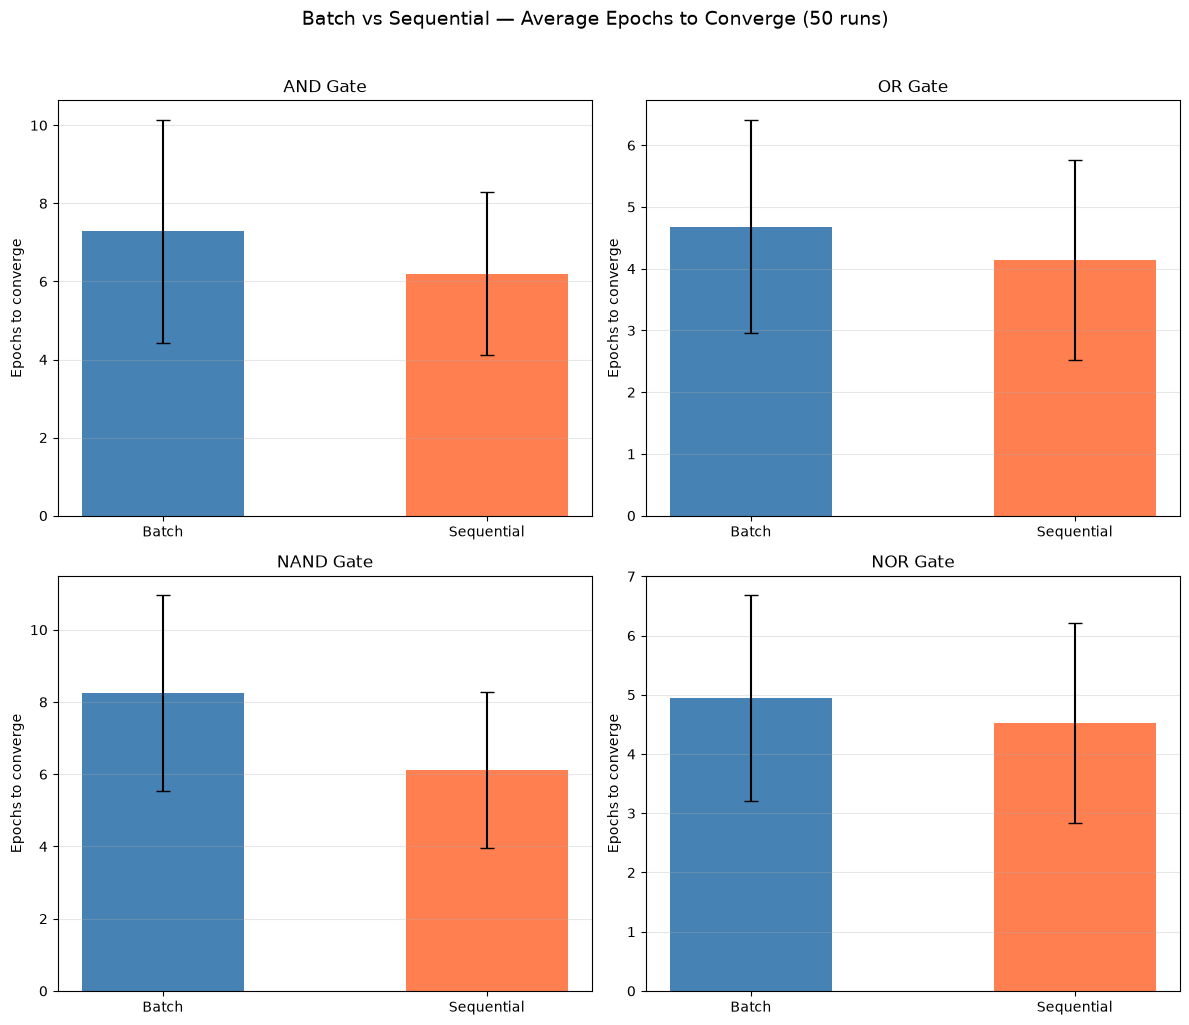

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def perceptron_batch(X, targets, learning_rate=0.25, max_epochs=100):
    n, f = X.shape
    Xb = np.concatenate([X, -np.ones((n, 1))], axis=1)
    w = np.random.uniform(-0.5, 0.5, f + 1)
    hist = []
    for _ in range(max_epochs):
        a = np.where(Xb @ w > 0, 1, 0)
        e = targets - a
        ne = np.sum(np.abs(e))
        hist.append(ne)
        if ne == 0: break
        w += learning_rate * (e @ Xb)
    return w, hist

def perceptron_sequential(X, targets, learning_rate=0.25, max_epochs=100):
    n, f = X.shape
    Xb = np.concatenate([X, -np.ones((n, 1))], axis=1)
    w = np.random.uniform(-0.5, 0.5, f + 1)
    hist = []
    for _ in range(max_epochs):
        ne = 0
        for i in range(n):
            a = 1 if Xb[i] @ w > 0 else 0
            err = targets[i] - a
            if err != 0:
                ne += 1
                w += learning_rate * err * Xb[i]
        hist.append(ne)
        if ne == 0: break
    return w, hist

X = np.array([[0,0],[0,1],[1,0],[1,1]])
gates = {
    'AND': np.array([0, 0, 0, 1]),
    'OR':  np.array([0, 1, 1, 1]),
    'NAND': np.array([1, 1, 1, 0]),
    'NOR': np.array([1, 0, 0, 0]),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, t) in zip(axes.flat, gates.items()):
    bl, sl = [], []
    for seed in range(50):
        np.random.seed(seed); _, eb = perceptron_batch(X, t)
        np.random.seed(seed); _, es = perceptron_sequential(X, t)
        bl.append(len(eb)); sl.append(len(es))
    ax.bar([0,1], [np.mean(bl), np.mean(sl)], yerr=[np.std(bl), np.std(sl)],
           color=['steelblue','coral'], capsize=5, width=0.5)
    ax.set_xticks([0,1]); ax.set_xticklabels(['Batch','Sequential'])
    ax.set_ylabel('Epochs to converge'); ax.set_title(f'{name} Gate'); ax.grid(axis='y', alpha=0.3)
fig.suptitle('Batch vs Sequential — Average Epochs to Converge (50 runs)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

### Observations

- Sequential update learns faster across all four gates because it fixes mistakes immediately instead of waiting until the end of each round.
- Batch update is more stable but slower since it averages all errors before making one change.
- Both methods reach the correct answer for all linearly separable gates. The final weights differ, but both draw a valid decision boundary.

## Question 5: Perceptron on the Pima Indians Diabetes Dataset

The Pima Indians Diabetes dataset contains 768 patient records with 8 medical features (glucose level, BMI, age, etc.). The goal is to predict whether a patient has diabetes or not.

**Dataset overview:**
- 768 total patients: 500 non-diabetic, 268 diabetic
- 8 input features, 1 output (diabetic or not)
- Data was normalized to a 0–1 range so that no single feature dominates the learning
- Split into 614 training samples and 154 test samples

The histograms below show how the features are distributed for each class. Notice that the two groups overlap heavily — there is no clean separation between diabetic and non-diabetic patients in any single feature.

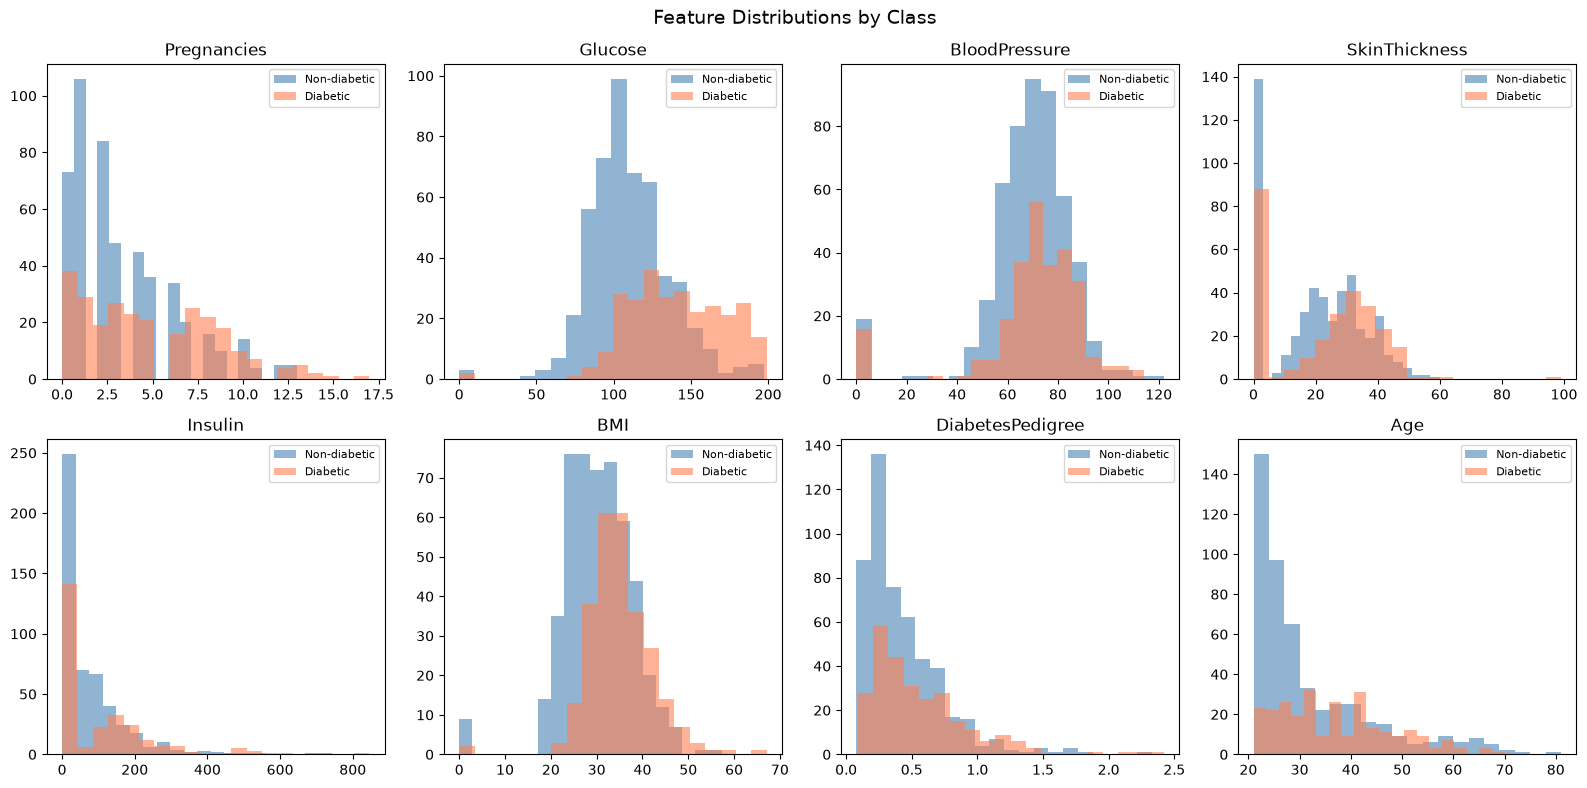

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
try:
    data = np.genfromtxt(url, delimiter=',')
except Exception:
    data = np.genfromtxt('pima-indians-diabetes.csv', delimiter=',')

feature_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                 'Insulin', 'BMI', 'DiabetesPedigree', 'Age']
X = data[:, :-1]
y = data[:, -1].astype(int)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, (ax, name) in enumerate(zip(axes.flat, feature_names)):
    ax.hist(X[y==0, i], bins=20, alpha=0.6, label='Non-diabetic', color='steelblue')
    ax.hist(X[y==1, i], bins=20, alpha=0.6, label='Diabetic', color='coral')
    ax.set_title(name)
    ax.legend(fontsize=8)
fig.suptitle('Feature Distributions by Class', fontsize=14)
plt.tight_layout()
plt.show()

### Perceptron Results

Both batch and sequential perceptrons were trained on this dataset for 200 epochs.

| Method | Epochs Run | Training Errors (out of 614) | Test Accuracy |
|--------|-----------|------------------------------|---------------|
| Batch | 200 | 197 | 58.4% |
| Sequential | 200 | 182 | 71.4% |

The training error convergence and confusion matrices are shown below:

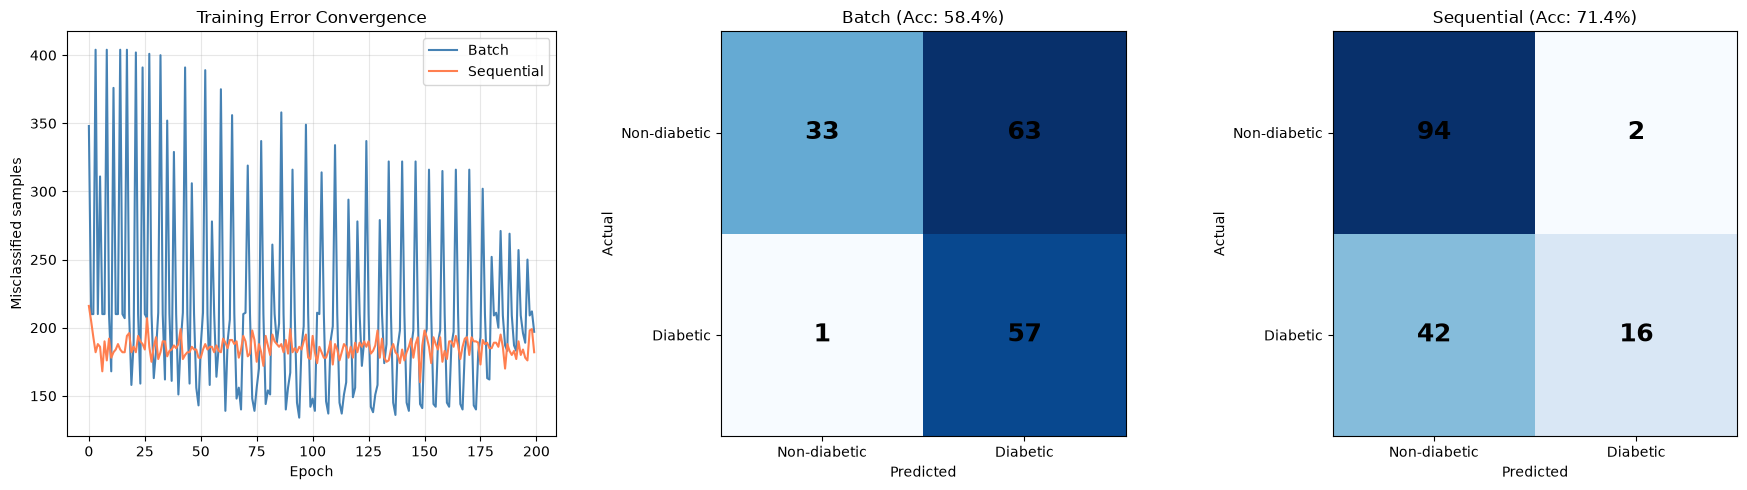

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Load and prepare data
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
try:
    data = np.genfromtxt(url, delimiter=',')
except Exception:
    data = np.genfromtxt('pima-indians-diabetes.csv', delimiter=',')

X = data[:, :-1]
y = data[:, -1].astype(int)

# Normalize
X_min, X_max = X.min(axis=0), X.max(axis=0)
X_norm = (X - X_min) / (X_max - X_min + 1e-8)

# Split
np.random.seed(42)
idx = np.random.permutation(len(X_norm))
split = int(0.8 * len(X_norm))
X_train, X_test = X_norm[idx[:split]], X_norm[idx[split:]]
y_train, y_test = y[idx[:split]], y[idx[split:]]

def train(X, t, mode, lr=0.25, epochs=200):
    n, f = X.shape
    Xb = np.concatenate([X, -np.ones((n,1))], axis=1)
    w = np.random.uniform(-0.1, 0.1, f+1)
    hist = []
    for _ in range(epochs):
        if mode == 'batch':
            a = np.where(Xb @ w > 0, 1, 0)
            e = t - a
            ne = np.sum(np.abs(e))
            hist.append(ne)
            if ne == 0: break
            w += lr * (e @ Xb)
        else:
            ne = 0
            for i in range(n):
                a = 1 if Xb[i] @ w > 0 else 0
                err = t[i] - a
                if err != 0:
                    ne += 1
                    w += lr * err * Xb[i]
            hist.append(ne)
            if ne == 0: break
    return w, hist

def predict(X, w):
    Xb = np.concatenate([X, -np.ones((X.shape[0],1))], axis=1)
    return np.where(Xb @ w > 0, 1, 0)

np.random.seed(42)
wb, eb = train(X_train, y_train, 'batch')
np.random.seed(42)
ws, es = train(X_train, y_train, 'sequential')

pb, ps = predict(X_test, wb), predict(X_test, ws)
ab, as_ = np.mean(pb==y_test)*100, np.mean(ps==y_test)*100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(eb, label='Batch', color='steelblue', linewidth=1.5)
axes[0].plot(es, label='Sequential', color='coral', linewidth=1.5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Misclassified samples')
axes[0].set_title('Training Error Convergence'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

def conf(ax, yt, yp, title):
    tp=np.sum((yt==1)&(yp==1)); tn=np.sum((yt==0)&(yp==0))
    fp=np.sum((yt==0)&(yp==1)); fn=np.sum((yt==1)&(yp==0))
    cm=np.array([[tn,fp],[fn,tp]])
    ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j,i,str(cm[i,j]),ha='center',va='center',fontsize=18,fontweight='bold')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Non-diabetic','Diabetic']); ax.set_yticklabels(['Non-diabetic','Diabetic'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title(title)

conf(axes[1], y_test, pb, f'Batch (Acc: {ab:.1f}%)')
conf(axes[2], y_test, ps, f'Sequential (Acc: {as_:.1f}%)')
plt.tight_layout(); plt.show()

### Observations

- The perceptron never reaches zero errors on this dataset. This is because the data is **not linearly separable** — the two classes overlap too much for a single straight line to separate them perfectly.
- The training error keeps bouncing up and down instead of smoothly going down. This is the Perceptron Cycling Theorem — when data cannot be separated, the perceptron keeps going in circles.
- Sequential update gives better accuracy (71.4%) than batch (58.4%) on this dataset.
- Glucose and BMI are the features that show the most difference between diabetic and non-diabetic groups, as seen in the histograms above.
- Normalizing the data was necessary because some features have very large ranges (Insulin goes up to 846) while others are very small (DiabetesPedigree maxes at 2.4). Without normalization, the large features would take over the learning.